In [52]:
from typing import List, Tuple

IMG_SIZE : int = 150
CHANNELS : int = 1

Layer = Tuple[int, str]
LAYERS : List[Layer] = [
    (128, 'relu'),
    (64, 'relu'),
    (1, 'sigmoid')
]
LEARNING_RATE : float = 0.001

EPOCHS : int = 10
BATCH_SIZE : int = 32

VERSION = "v1_base" + str(LAYERS) + f"_lr{LEARNING_RATE}" + f"_epochs{EPOCHS}" + f"_batch{BATCH_SIZE}"


from IPython.display import Markdown, display
def md(text): display(Markdown(text))

In [53]:
md(f"""
## Étape 1 : Charger et prétraiter les données

Cette première étape configure l'environnement et prépare les images de radiographies pour l'entraînement du modèle.

### Configuration du prétraitement
Nous définissons deux constantes importantes :
- **IMG_SIZE = {IMG_SIZE}** : Correspond aux dimensions des images redimensionnées ({IMG_SIZE}×{IMG_SIZE} pixels) pour uniformiser les entrées du modèle
- **CHANNELS = {CHANNELS}** : Les images sont en niveaux de gris, donc nous avons une seule couche de couleur au lieu de trois (R, G, B).

### `load_data_from_folder()`
Cette fonction parcourt automatiquement les sous-dossiers `NORMAL` et `PNEUMONIA` du dataset et effectue les opérations suivantes :

1. **Chargement** : Lecture de chaque image en niveaux de gris avec OpenCV
2. **Redimensionnement** : Transformation en {IMG_SIZE}×{IMG_SIZE} pixels pour que toutes les images aient la même taille
3. **Normalisation** : Conversion des valeurs de pixels de [0, 255] vers [0, 1] en divisant par 255
4. **Labellisation** : Attribution d'un label 0 (NORMAL) ou 1 (PNEUMONIA) pour chaque image

### Pourquoi normaliser?
Les valeurs de pixels normalisées entre 0 et 1 aident le réseau de neurones à converger plus rapidement pendant l'apprentissage et améliore la stabilité numérique des calculs.

### Structure de sortie
La fonction retourne deux tableaux numpy :
- **data** : tableau des images prétraitées (forme : nombre_images × {IMG_SIZE} × {IMG_SIZE})
- **labels** : tableau des étiquettes correspondantes (0 ou 1)
""")


## Étape 1 : Charger et prétraiter les données

Cette première étape configure l'environnement et prépare les images de radiographies pour l'entraînement du modèle.

### Configuration du prétraitement
Nous définissons deux constantes importantes :
- **IMG_SIZE = 150** : Correspond aux dimensions des images redimensionnées (150×150 pixels) pour uniformiser les entrées du modèle
- **CHANNELS = 1** : Les images sont en niveaux de gris, donc nous avons une seule couche de couleur au lieu de trois (R, G, B).

### `load_data_from_folder()`
Cette fonction parcourt automatiquement les sous-dossiers `NORMAL` et `PNEUMONIA` du dataset et effectue les opérations suivantes :

1. **Chargement** : Lecture de chaque image en niveaux de gris avec OpenCV
2. **Redimensionnement** : Transformation en 150×150 pixels pour que toutes les images aient la même taille
3. **Normalisation** : Conversion des valeurs de pixels de [0, 255] vers [0, 1] en divisant par 255
4. **Labellisation** : Attribution d'un label 0 (NORMAL) ou 1 (PNEUMONIA) pour chaque image

### Pourquoi normaliser?
Les valeurs de pixels normalisées entre 0 et 1 aident le réseau de neurones à converger plus rapidement pendant l'apprentissage et améliore la stabilité numérique des calculs.

### Structure de sortie
La fonction retourne deux tableaux numpy :
- **data** : tableau des images prétraitées (forme : nombre_images × 150 × 150)
- **labels** : tableau des étiquettes correspondantes (0 ou 1)


In [54]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def load_data_from_folder(parent_path):
    data = []
    labels = []
    categories = {'NORMAL': 0, 'PNEUMONIA': 1}
    
    for category, label in categories.items():
        path = os.path.join(parent_path, category)
        if not os.path.exists(path):
            continue
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                data.append(img)
                labels.append(label)
            except Exception as e:
                pass
      
    return np.array(data), np.array(labels)

In [55]:
X_train, y_train = load_data_from_folder('../data/train')
print(f"Train images loaded : {len(X_train)}")
X_val, y_val = load_data_from_folder('../data/val')
print(f"Validation images loaded : {len(X_val)}")
X_test, y_test = load_data_from_folder('../data/test')
print(f"Test images loaded : {len(X_test)}")

Train images loaded : 5216
Validation images loaded : 16
Test images loaded : 624


In [56]:
md(f"""
## Étape 2 : Visualisation et vérification

On utilise `cmap='gray'` pour afficher les images en niveaux de gris, ce qui correspond au format original des radiographies médicales.

### Objectifs de cette étape

- Vérifier que les images ont bien été redimensionnées en {IMG_SIZE}×{IMG_SIZE} pixels
- Confirmer que la normalisation a été appliquée (pixels entre 0 et 1)
- Observer visuellement la différence entre les radiographies normales et celles avec pneumonie

### Résultat attendu
Deux graphiques côte à côte :

**À gauche** : Une radiographie d'un poumon normal (Label 0)
</br>
**À droite** : Une radiographie d'un poumon avec pneumonie (Label 1)
""")


## Étape 2 : Visualisation et vérification

On utilise `cmap='gray'` pour afficher les images en niveaux de gris, ce qui correspond au format original des radiographies médicales.

### Objectifs de cette étape

- Vérifier que les images ont bien été redimensionnées en 150×150 pixels
- Confirmer que la normalisation a été appliquée (pixels entre 0 et 1)
- Observer visuellement la différence entre les radiographies normales et celles avec pneumonie

### Résultat attendu
Deux graphiques côte à côte :

**À gauche** : Une radiographie d'un poumon normal (Label 0)
</br>
**À droite** : Une radiographie d'un poumon avec pneumonie (Label 1)


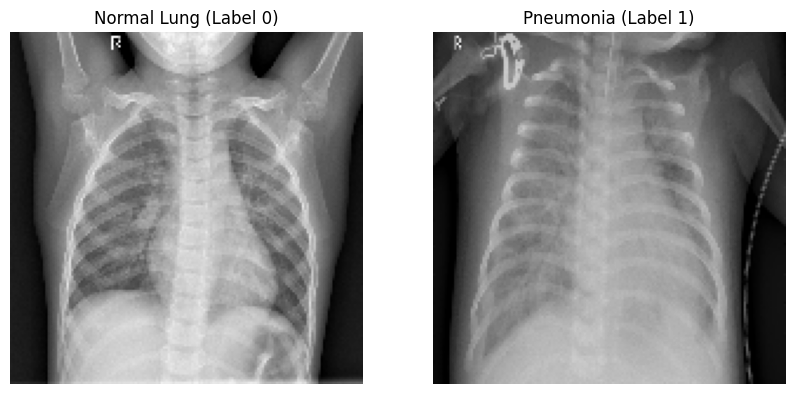

In [57]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(X_train[y_train == 0][0], cmap='gray')
plt.title("Normal Lung (Label 0)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(X_train[y_train == 1][0], cmap='gray')
plt.title("Pneumonia (Label 1)")
plt.axis('off')

plt.show()

In [58]:
md(f"""
## Étape 3 : Définition de l'architecture du modèle

Nous construisons un réseau de neurones artificiels (ANN - Artificial Neural Network) pour la classification binaire.

Le résumé du modèle affiche le nombre total de paramètres entraînables.

### Architecture du modèle

- **Flatten** : Transforme l'image 2D ({IMG_SIZE}×{IMG_SIZE}) en un vecteur 1D de {IMG_SIZE * IMG_SIZE} valeurs
   - Nécessaire car les couches Dense n'acceptent que des entrées 1D
   - Aucun paramètre à entraîner, c'est juste une transformation

### Couches

1. **Dense({LAYERS[0][0]}, activation='{LAYERS[0][1]}')** : Première couche cachée
   - {LAYERS[0][0]} neurones interconnectés
   - Fonction d'activation ReLU (Rectified Linear Unit) pour introduire de la non-linéarité

2. **Dense({LAYERS[1][0]}, activation='{LAYERS[1][1]}')** : Deuxième couche cachée
   - {LAYERS[1][0]} neurones pour affiner les représentations
   - Permet au modèle d'apprendre des patterns complexes
   - Réduction progressive du nombre de neurones ({LAYERS[0][0]} → {LAYERS[1][0]} → {LAYERS[2][0]})

3. **Dense({LAYERS[2][0]}, activation='{LAYERS[2][1]}')** : Couche de sortie
   - 1 seul neurone (classification binaire)
   - Activation sigmoid pour obtenir une probabilité entre 0 et 1
   - Sortie proche de 0 = NORMAL, proche de 1 = PNEUMONIE

### Compilation du modèle

- **Optimizer** : Adam avec learning_rate = {LEARNING_RATE} (ajuste les poids du réseau)
- **Loss** : binary_crossentropy (fonction de perte pour classification binaire)
- **Metrics** : accuracy (pourcentage de prédictions correctes)
""")


## Étape 3 : Définition de l'architecture du modèle

Nous construisons un réseau de neurones artificiels (ANN - Artificial Neural Network) pour la classification binaire.

Le résumé du modèle affiche le nombre total de paramètres entraînables.

### Architecture du modèle

- **Flatten** : Transforme l'image 2D (150×150) en un vecteur 1D de 22500 valeurs
   - Nécessaire car les couches Dense n'acceptent que des entrées 1D
   - Aucun paramètre à entraîner, c'est juste une transformation

### Couches

1. **Dense(128, activation='relu')** : Première couche cachée
   - 128 neurones interconnectés
   - Fonction d'activation ReLU (Rectified Linear Unit) pour introduire de la non-linéarité

2. **Dense(64, activation='relu')** : Deuxième couche cachée
   - 64 neurones pour affiner les représentations
   - Permet au modèle d'apprendre des patterns complexes
   - Réduction progressive du nombre de neurones (128 → 64 → 1)

3. **Dense(1, activation='sigmoid')** : Couche de sortie
   - 1 seul neurone (classification binaire)
   - Activation sigmoid pour obtenir une probabilité entre 0 et 1
   - Sortie proche de 0 = NORMAL, proche de 1 = PNEUMONIE

### Compilation du modèle

- **Optimizer** : Adam avec learning_rate = 0.001 (ajuste les poids du réseau)
- **Loss** : binary_crossentropy (fonction de perte pour classification binaire)
- **Metrics** : accuracy (pourcentage de prédictions correctes)


In [59]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE)),
    *[layers.Dense(units, activation=activation) for units, activation in LAYERS]
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_4 (Flatten)         (None, 22500)             0         
                                                                 
 dense_12 (Dense)            (None, 128)               2880128   
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dense_14 (Dense)            (None, 1)                 65        
                                                                 
Total params: 2,888,449
Trainable params: 2,888,449
Non-trainable params: 0
_________________________________________________________________


In [60]:
md(f"""
## Étape 4 : Entraînement du modèle

`history` stocke l'évolution des métriques (accuracy, loss) pour analyse ultérieure.

### Processus d'entraînement

La fonction `model.fit()` effectue l'apprentissage supervisé :

- Le modèle analyse les images d'entraînement (`X_train`)
- Compare ses prédictions avec les vraies étiquettes (`y_train`)
- Ajuste ses poids internes pour minimiser l'erreur
- Répète ce processus sur plusieurs époques ({EPOCHS} fois) pour améliorer progressivement les performances

### Paramètres d'entraînement

- **epochs={EPOCHS}** : Le modèle parcourt l'intégralité du dataset {EPOCHS} fois
  - Chaque époque améliore progressivement les prédictions
  - Si la précision train augmente mais val stagne/baisse → sur-apprentissage
  
- **batch_size={BATCH_SIZE}** : Nombre d'images traitées simultanément
  - Plus rapide que de traiter image par image
  - Compromis entre vitesse et stabilité de l'apprentissage

- **validation_data=(X_val, y_val)** : Surveillance en temps réel
  - À chaque époque, le modèle est testé sur les données de validation
  - Permet de détecter le sur-apprentissage (overfitting)
""")


## Étape 4 : Entraînement du modèle

`history` stocke l'évolution des métriques (accuracy, loss) pour analyse ultérieure.

### Processus d'entraînement

La fonction `model.fit()` effectue l'apprentissage supervisé :

- Le modèle analyse les images d'entraînement (`X_train`)
- Compare ses prédictions avec les vraies étiquettes (`y_train`)
- Ajuste ses poids internes pour minimiser l'erreur
- Répète ce processus sur plusieurs époques (10 fois) pour améliorer progressivement les performances

### Paramètres d'entraînement

- **epochs=10** : Le modèle parcourt l'intégralité du dataset 10 fois
  - Chaque époque améliore progressivement les prédictions
  - Si la précision train augmente mais val stagne/baisse → sur-apprentissage
  
- **batch_size=32** : Nombre d'images traitées simultanément
  - Plus rapide que de traiter image par image
  - Compromis entre vitesse et stabilité de l'apprentissage

- **validation_data=(X_val, y_val)** : Surveillance en temps réel
  - À chaque époque, le modèle est testé sur les données de validation
  - Permet de détecter le sur-apprentissage (overfitting)


In [61]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS, 
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE
)

Epoch 1/10
163/163 [==============================] - 3s 14ms/step - loss: 0.8923 - accuracy: 0.7958 - val_loss: 0.5565 - val_accuracy: 0.8750
Epoch 2/10
163/163 [==============================] - 2s 13ms/step - loss: 0.1712 - accuracy: 0.9293 - val_loss: 0.2704 - val_accuracy: 0.9375
Epoch 3/10
163/163 [==============================] - 2s 13ms/step - loss: 0.1521 - accuracy: 0.9398 - val_loss: 0.7335 - val_accuracy: 0.6875
Epoch 4/10
163/163 [==============================] - 2s 13ms/step - loss: 0.2102 - accuracy: 0.9216 - val_loss: 0.5182 - val_accuracy: 0.8125
Epoch 5/10
163/163 [==============================] - 2s 13ms/step - loss: 0.1727 - accuracy: 0.9335 - val_loss: 0.3995 - val_accuracy: 0.8750
Epoch 6/10
163/163 [==============================] - 2s 13ms/step - loss: 0.1381 - accuracy: 0.9469 - val_loss: 0.5236 - val_accuracy: 0.8125
Epoch 7/10
163/163 [==============================] - 2s 13ms/step - loss: 0.1158 - accuracy: 0.9576 - val_loss: 0.2762 - val_accuracy: 0.9375

In [62]:
save_path = f'../models/zoidberg_model_{VERSION}.keras'

model.save(save_path)
print(f"Model saved to : {save_path}")

Model saved to : ../models/zoidberg_model_v1_base[(128, 'relu'), (64, 'relu'), (1, 'sigmoid')]_lr0.001_epochs10_batch32.keras


In [63]:
md("""
## Étape 5 : Évaluation avec la courbe ROC

### Courbe ROC
- **TPR (True Positive Rate)** : Taux de vrais positifs (sensibilité) → combien de cas de pneumonie sont correctement détectés
- **FPR (False Positive Rate)** : Taux de faux positifs → combien de cas en bonne santé sont incorrectement classés comme pneumonie

### Graphique
- **Ligne bleue** : Performance du modèle
- **Ligne rouge pointillée** : Classifieur aléatoire (référence)
- Plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche, meilleur est le modèle
""")


## Étape 5 : Évaluation avec la courbe ROC

### Courbe ROC
- **TPR (True Positive Rate)** : Taux de vrais positifs (sensibilité) → combien de cas de pneumonie sont correctement détectés
- **FPR (False Positive Rate)** : Taux de faux positifs → combien de cas en bonne santé sont incorrectement classés comme pneumonie

### Graphique
- **Ligne bleue** : Performance du modèle
- **Ligne rouge pointillée** : Classifieur aléatoire (référence)
- Plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche, meilleur est le modèle


20/20 [==============================] - 0s 2ms/step


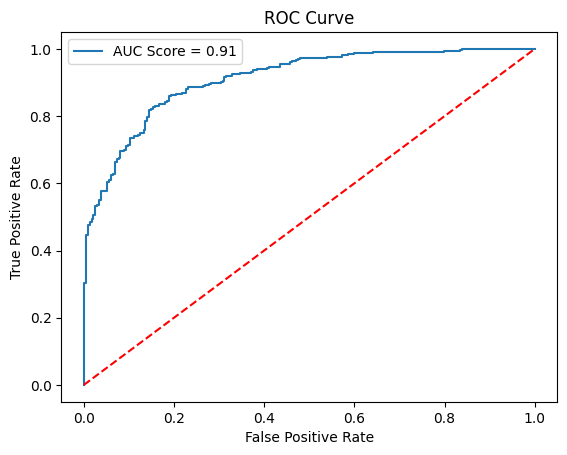

In [64]:
y_probs = model.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC Score = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()